In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('fitlife.csv')
df.head()

,ID,Date,Age,Gender,Employment Status,Time of day,Activity Category,Sub-Activity,Activity,Duration (minutes),Intensity,Primary Emotion,Secondary Emotion,Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10)
0,1,2024-06-15,34,Male,Retired,Afternoon,Physical - Exercise,Mind-Body,Stretching,79,High,Energized,Challenged,3,3,6,9
1,2,2024-02-24,30,Prefer not to say,Retired,Night,Physical - Sports,Extreme Sports,Bungee Jumping,72,High,Accomplished,Accomplished,6,7,4,9
2,3,2024-06-05,75,Female,Employed,Night,Relaxation,Entertainment,Music Listening,117,High,Energized,Recharged,7,8,7,6
3,4,2024-06-05,28,Prefer not to say,Retired,Night,Relaxation,Leisure,Baking,78,High,Accomplished,Serene,7,8,8,9
4,5,2024-01-05,75,Female,Student,Afternoon,Physical - Sports,Team Sports,Basketball,55,Medium,Flexible,Challenged,7,8,6,2


In [3]:
df.describe()

,ID,Age,Duration (minutes),Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10)
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,48.888790,86.414320,5.482810,5.768820,4.623950,4.760000
std,28867.657797,18.181238,38.121409,1.707938,2.004374,1.694068,2.168402
min,1.000000,18.000000,15.000000,3.000000,2.000000,2.000000,2.000000
25%,25000.750000,33.000000,56.000000,4.000000,4.000000,3.000000,3.000000
50%,50000.500000,49.000000,85.000000,5.000000,6.000000,5.000000,4.000000
75%,75000.250000,65.000000,114.000000,7.000000,7.000000,6.000000,6.000000
max,100000.000000,80.000000,180.000000,8.000000,10.000000,8.000000,9.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   ID                    100000 non-null  int64 
 1   Date                  100000 non-null  object
 2   Age                   100000 non-null  int64 
 3   Gender                100000 non-null  object
 4   Employment Status     100000 non-null  object
 5   Time of day           100000 non-null  object
 6   Activity Category     100000 non-null  object
 7   Sub-Activity          100000 non-null  object
 8   Activity              100000 non-null  object
 9   Duration (minutes)    100000 non-null  int64 
 10  Intensity             100000 non-null  object
 11  Primary Emotion       100000 non-null  object
 12  Secondary Emotion     100000 non-null  object
 13  Mood Before (1-10)    100000 non-null  int64 
 14  Mood After(1-10)      100000 non-null  int64 
 15  Energy Level (1-10

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('Numerical Columns', numeric_cols) 
print('Categorical Columns',categorical_cols)

Numerical Columns ['ID', 'Age', 'Duration (minutes)', 'Mood Before (1-10)', 'Mood After(1-10)', 'Energy Level (1-10)', 'Stress level (1 -10)']
Categorical Columns ['Date', 'Gender', 'Employment Status', 'Time of day', 'Activity Category', 'Sub-Activity', 'Activity', 'Intensity', 'Primary Emotion', 'Secondary Emotion']


In [6]:
df['Intensity'].unique()

array(['High', 'Medium', 'Low'], dtype=object)

<Axes: xlabel='Intensity', ylabel='Stress level (1 -10)'>

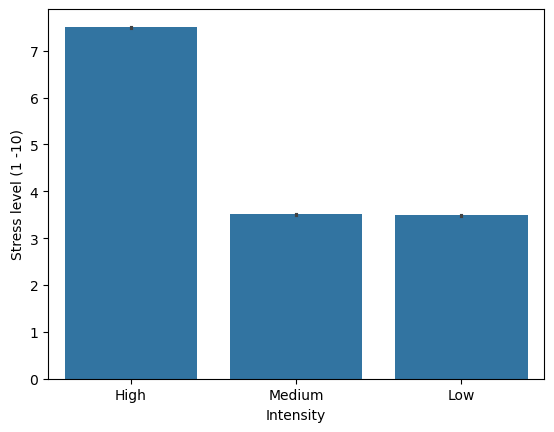

In [7]:
#The bar plot reveals that people are stressed when they engaged in High intensity activities above level 4
sns.barplot(data=df, y='Stress level (1 -10)', x='Intensity')

<Axes: xlabel='Energy Level (1-10)', ylabel='Stress level (1 -10)'>

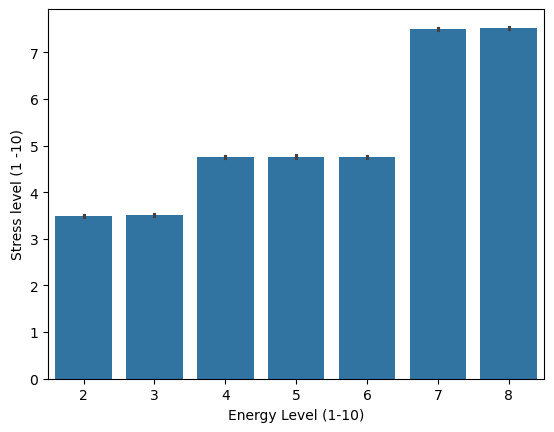

In [8]:
#The bar chart displays individuals with very high Energy level of 7 and 8 are most stressed.
sns.barplot(data=df, y='Stress level (1 -10)', x='Energy Level (1-10)')

<Axes: xlabel='Energy Level (1-10)', ylabel='Stress level (1 -10)'>

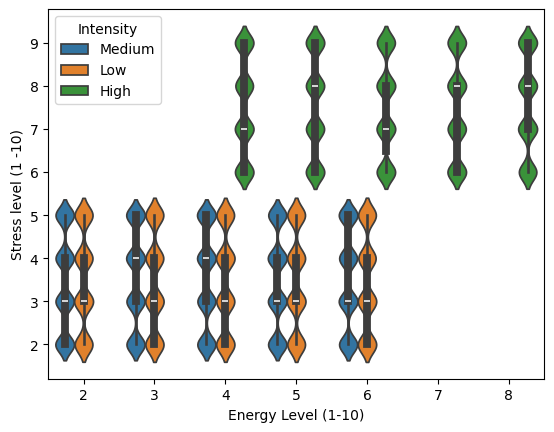

In [9]:
#From the violin plot, we can see that people with the stress level of above 5 are involved in high intensity activity 
#and mostly have high energy level. 
sns.violinplot(data=df, hue='Intensity', x='Energy Level (1-10)', y= 'Stress level (1 -10)')

<Axes: xlabel='Intensity', ylabel='Age'>

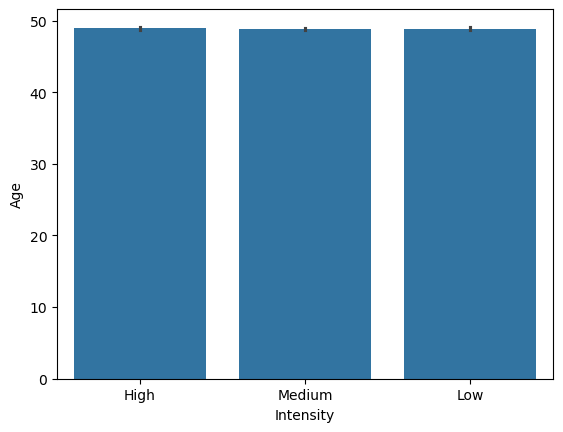

In [10]:
#The bar plot displays an even distribution of age groups and intensity of activities which also results in stress level. 
#From this analysis, Age may not be regarded as a factor determining stress level
sns.barplot(data=df, y='Age', x= 'Intensity')

<Axes: xlabel='Time of day', ylabel='Stress level (1 -10)'>

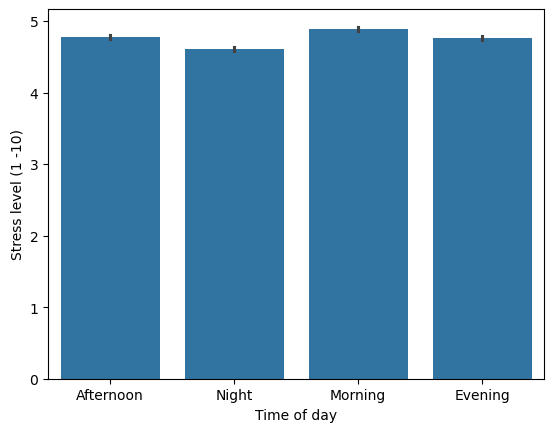

In [11]:
#The bar chart shows that "time of day" is significant to determine stress level.
sns.barplot(data=df, x='Time of day', y= 'Stress level (1 -10)')

<Axes: xlabel='Energy Level (1-10)'>

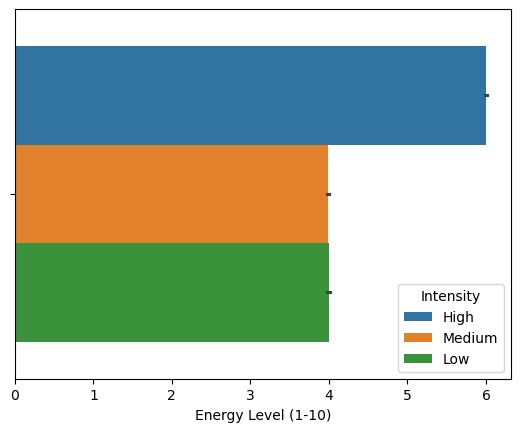

In [12]:
sns.barplot(data=df, hue='Intensity', x='Energy Level (1-10)')

<Axes: ylabel='Gender'>

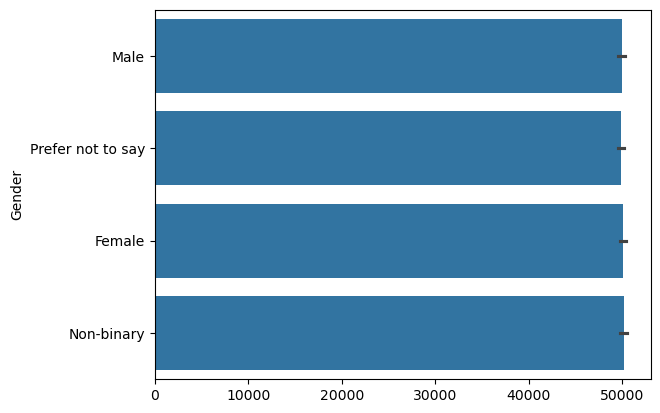

In [13]:
sns.barplot(data=df['Gender'])

<Axes: xlabel='Gender', ylabel='Stress level (1 -10)'>

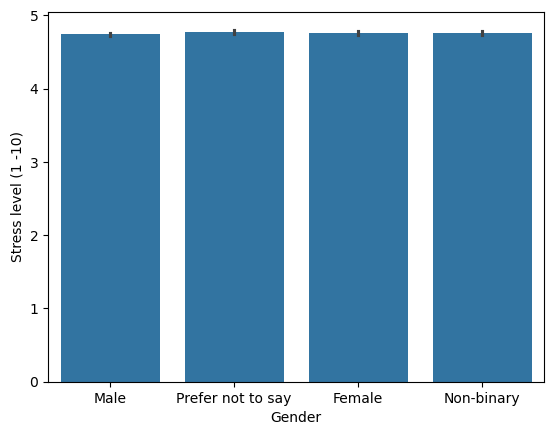

In [14]:
sns.barplot(data=df, x='Gender', y= 'Stress level (1 -10)')

In [15]:
df_1 = df.copy()

In [16]:
# I mappped the genders to Prefer not to say: 0, Non binary: 1, Male : 2 and Female : 3 to create a numeric values for ML learning model

df_1['Gender'] = df_1['Gender'].map({'Prefer not to say' : 0, 'Non-binary' : 1, 'Male' : 2, 'Female' : 3})

In [17]:
df_2 = df_1.copy()

In [18]:
#I mapped the intensity objects Low : 0, Medium : 1, High : 2
df_2['Intensity'] = df_2['Intensity'].map({'Low' : 0, 'Medium' : 1, 'High' : 2})

In [19]:
df_3 = df_2.copy()

In [20]:
#I mapped the time of day 'Afternoon' : 0, 'Night' : 1, 'Morning' : 2, 'Evening': 3
df_3['Time of day'] = df_3['Time of day'].map({'Afternoon' : 0, 'Night' : 1, 'Morning' : 2, 'Evening': 3})

In [21]:

df_4 = df_3.drop(['Age','Time of day', 'ID', 'Date', 'Employment Status', 
                  'Activity Category', 'Sub-Activity', 'Activity', 'Primary Emotion', 'Secondary Emotion'], axis=1)

In [22]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Gender                100000 non-null  int64
 1   Duration (minutes)    100000 non-null  int64
 2   Intensity             100000 non-null  int64
 3   Mood Before (1-10)    100000 non-null  int64
 4   Mood After(1-10)      100000 non-null  int64
 5   Energy Level (1-10)   100000 non-null  int64
 6   Stress level (1 -10)  100000 non-null  int64
dtypes: int64(7)
memory usage: 5.3 MB


In [23]:
df_4.describe()

,Gender,Duration (minutes),Intensity,Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10)
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.502500,86.414320,1.054660,5.482810,5.768820,4.623950,4.760000
std,1.118198,38.121409,0.756636,1.707938,2.004374,1.694068,2.168402
min,0.000000,15.000000,0.000000,3.000000,2.000000,2.000000,2.000000
25%,1.000000,56.000000,0.000000,4.000000,4.000000,3.000000,3.000000
50%,2.000000,85.000000,1.000000,5.000000,6.000000,5.000000,4.000000
75%,3.000000,114.000000,2.000000,7.000000,7.000000,6.000000,6.000000
max,3.000000,180.000000,2.000000,8.000000,10.000000,8.000000,9.000000


In [24]:
from sklearn.linear_model import LogisticRegression
cls = LogisticRegression(max_iter = 1000)
X = df_4.drop('Stress level (1 -10)', axis = 1)
y = df_4['Stress level (1 -10)']
cls.fit(X, y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [25]:
y_pred = cls.predict(X)

In [26]:
sum(y_pred == y) / y.shape[0]

0.25238

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.25238

In [28]:
from sklearn.linear_model import LogisticRegression
cls = LogisticRegression(max_iter = 1000, random_state=100)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
cls.fit(X_train, y_train)

#Training Error
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))

#Validation(testing) Error
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.2525875
0.2489


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
df_test_4 = df_4.drop('Stress level (1 -10)', axis = 1)

In [30]:
X = df_4.drop('Stress level (1 -10)', axis = 1)
y = df_4['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)

new_test_X = scaler.transform(df_test_4)

from sklearn.ensemble import RandomForestClassifier
cls = RandomForestClassifier(random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
y_pred = cls.predict(new_test_X)
#pd.DataFrame({'PassengerId' : test_df.PassengerId, 'Survived' : y_pred}).to_csv('submit4.csv', index = None)

0.8481
0.2502


In [31]:
X.columns

Index(['Gender', 'Duration (minutes)', 'Intensity', 'Mood Before (1-10)',
       'Mood After(1-10)', 'Energy Level (1-10)'],
      dtype='object')

In [32]:
cls.feature_importances_

array([0.05049949, 0.6168842 , 0.12579093, 0.05173022, 0.07321335,
       0.08188181])

<Axes: >

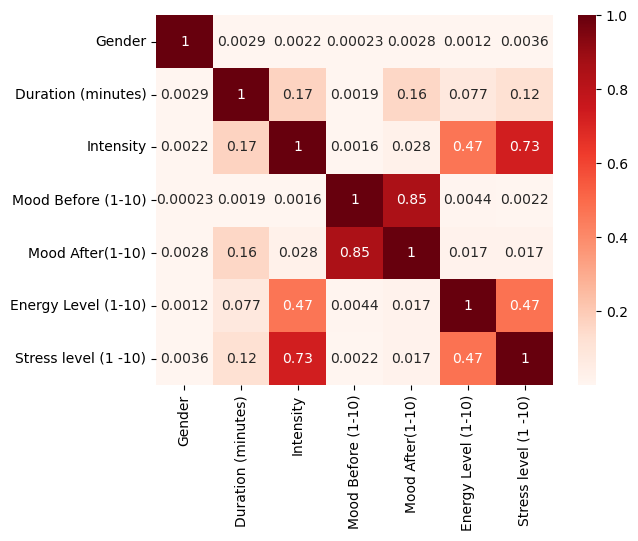

In [33]:
import seaborn as sns
sns.heatmap(df_4.corr().abs(), annot= True, cmap='Reds')

In [34]:
def categorize_stress_level(stress_level: int) -> int:
    """
    Categorizes stress level into binary values.
    
    Args:
        stress_level (int): The stress level value (expected range: 1-10)
        
    Returns:
        int: 1 if stress level is low to moderate (≤4), 0 if high (>4)
    """
    return 0 if stress_level <= 4 else 1

# Apply the categorization function to the stress level column
df_4['Stress level (1 -10)'] = df_4['Stress level (1 -10)'].apply(categorize_stress_level)

In [35]:
df_4

,Gender,Duration (minutes),Intensity,Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10)
0,2,79,2,3,3,6,1
1,0,72,2,6,7,4,1
2,3,117,2,7,8,7,1
3,0,78,2,7,8,8,1
4,3,55,1,7,8,6,0
...,...,...,...,...,...,...,...
99995,2,46,1,6,5,4,0
99996,2,70,1,5,6,6,0
99997,0,51,1,5,4,4,0
99998,3,149,1,8,7,5,1


In [36]:
X = df_4.drop('Stress level (1 -10)', axis = 1)
y = df_4['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)

new_test_X = scaler.transform(df_test_4)

from sklearn.ensemble import RandomForestClassifier
cls = RandomForestClassifier(random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
#y_pred = cls.predict(new_test_X)


0.9506
0.76475


In [37]:
#These line of codes will calculate the accuracy, confusion matrix and classification report of the model


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.76475
Confusion Matrix:
 [[8402 1908]
 [2797 6893]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78     10310
           1       0.78      0.71      0.75      9690

    accuracy                           0.76     20000
   macro avg       0.77      0.76      0.76     20000
weighted avg       0.77      0.76      0.76     20000



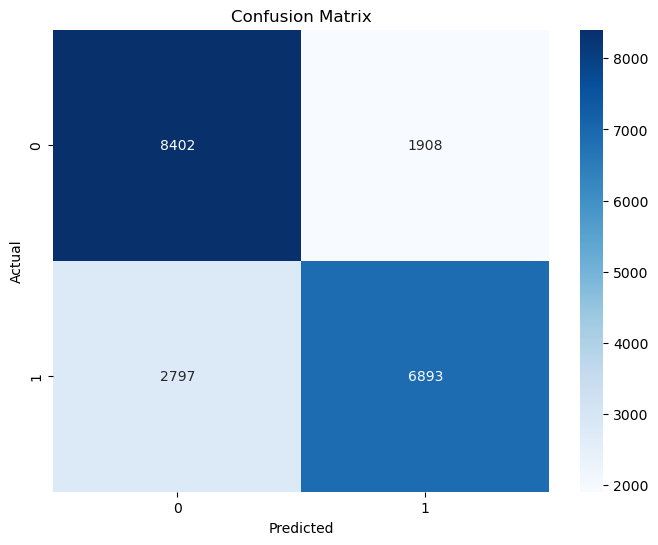

In [38]:
#Visualize a confusion matrix using heatmap 
#This Provides a clear graphical representation of the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
df_temp = pd.get_dummies(df_4.Intensity, prefix='Intensity', drop_first=True)
df_5 = df_4.drop('Intensity', axis = 1)
df_5 = pd.concat([df_5, df_temp], axis = 1)
df_temp = pd.get_dummies(df_test_4.Intensity, prefix='Intensity', drop_first=True)
df_test_5 = df_test_4.drop('Intensity', axis = 1)
df_test_5 = pd.concat([df_test_5, df_temp], axis = 1)
df_5

,Gender,Duration (minutes),Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10),Intensity_1,Intensity_2
0,2,79,3,3,6,1,False,True
1,0,72,6,7,4,1,False,True
2,3,117,7,8,7,1,False,True
3,0,78,7,8,8,1,False,True
4,3,55,7,8,6,0,True,False
...,...,...,...,...,...,...,...,...
99995,2,46,6,5,4,0,True,False
99996,2,70,5,6,6,0,True,False
99997,0,51,5,4,4,0,True,False
99998,3,149,8,7,5,1,True,False


In [40]:
X = df_5.drop('Stress level (1 -10)', axis = 1)
y = df_5['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)

new_test_X = scaler.transform(df_test_5)

from sklearn.ensemble import RandomForestClassifier
cls = RandomForestClassifier(random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
#y_pred = cls.predict(new_test_X)

0.9506
0.76255


In [41]:
#These line of codes will calculate the accuracy, confusion matrix and classification report of the model


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.76255
Confusion Matrix:
 [[8345 1965]
 [2784 6906]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78     10310
           1       0.78      0.71      0.74      9690

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



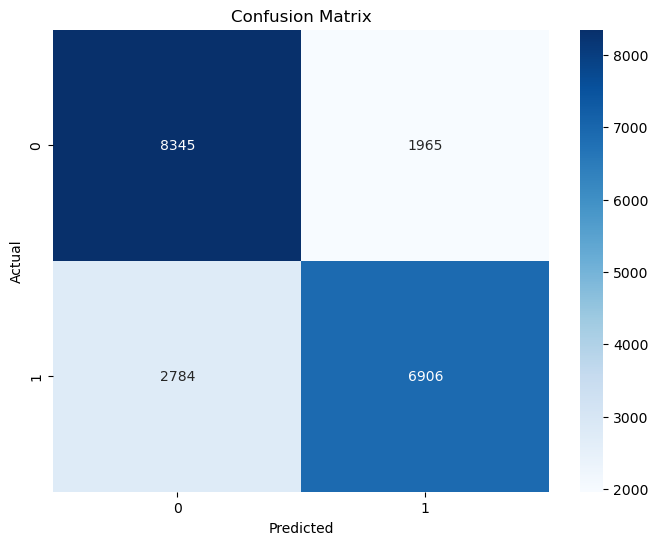

In [42]:
#Visualize a confusion matrix using heatmap 
#This Provides a clear graphical representation of the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [43]:
X = df_5.drop('Stress level (1 -10)', axis = 1)
y = df_5['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)
new_test_X = scaler.transform(df_test_5)
from sklearn.linear_model import LogisticRegression
cls = LogisticRegression(max_iter = 1000, random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
#y_pred = cls.predict(new_test_X)


0.829525
0.82865


In [44]:
#These line of codes will calculate the accuracy, confusion matrix and classification report of the model


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.82865
Confusion Matrix:
 [[10310     0]
 [ 3427  6263]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     10310
           1       1.00      0.65      0.79      9690

    accuracy                           0.83     20000
   macro avg       0.88      0.82      0.82     20000
weighted avg       0.87      0.83      0.82     20000



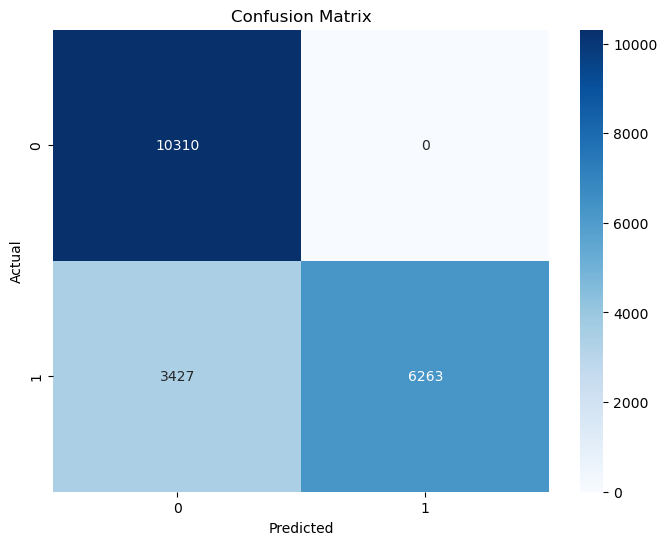

In [45]:
#Visualize a confusion matrix using heatmap 
#This Provides a clear graphical representation of the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [46]:
x = df_5.drop('Stress level (1 -10)', axis = 1)
y = df_5['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)
new_test_X = scaler.transform(df_test_5)
from xgboost import XGBClassifier
cls = XGBClassifier(random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
y_pred = cls.predict(new_test_X)
#pd.DataFrame({'PassengerId' : test_df.PassengerId, 'Survived' : y_pred}).to_csv('submit10.csv', index = None)

0.832275
0.82705


In [47]:
x = df_5.drop('Stress level (1 -10)', axis = 1)
y = df_5['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)
new_test_X = scaler.transform(df_test_5)
from xgboost import XGBClassifier
cls = XGBClassifier(random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
#y_pred = cls.predict(new_test_X)

0.832275
0.82705


In [48]:
#These line of codes will calculate the accuracy, confusion matrix and classification report of the model


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.82705
Confusion Matrix:
 [[10263    47]
 [ 3412  6278]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     10310
           1       0.99      0.65      0.78      9690

    accuracy                           0.83     20000
   macro avg       0.87      0.82      0.82     20000
weighted avg       0.87      0.83      0.82     20000



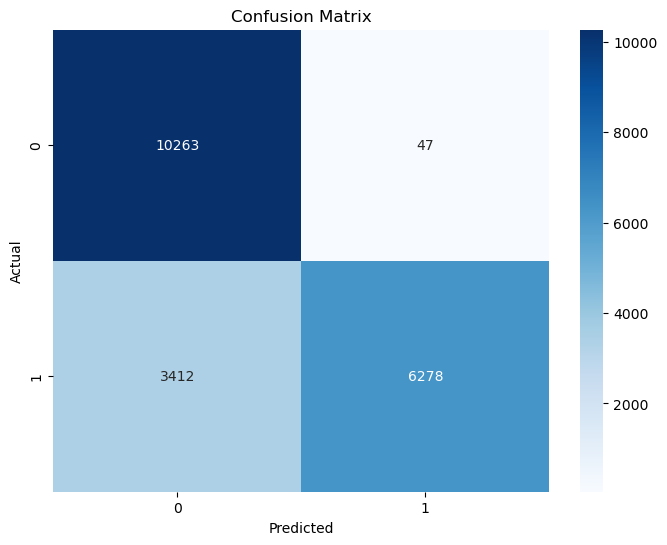

In [49]:
#Visualize a confusion matrix using heatmap 
#This Provides a clear graphical representation of the confusion matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Axes: >

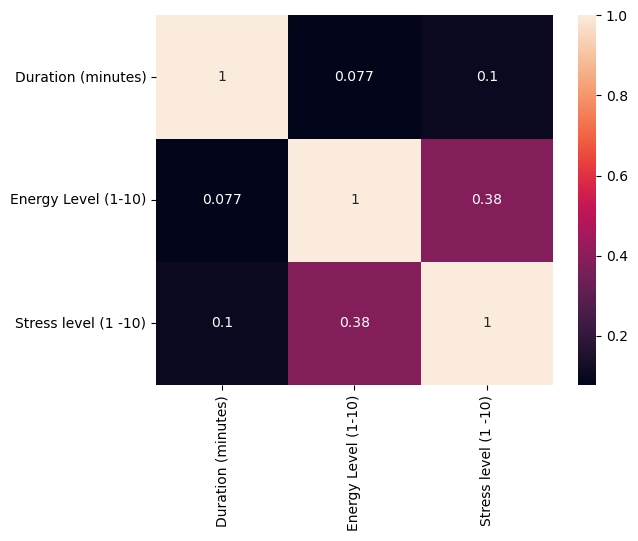

In [50]:
df_6 = df_5.drop(['Intensity_1','Intensity_2', 'Gender', 'Mood Before (1-10)', 'Mood After(1-10)'], axis=1)

import seaborn as sns
sns.heatmap(df_6.corr().abs(), annot= True)

In [51]:
df_temp = pd.get_dummies(df_5.Gender, prefix='Gender', drop_first=True)
df_7 = df_5.drop('Gender', axis = 1)
df_7 = pd.concat([df_7, df_temp], axis = 1)
df_temp = pd.get_dummies(df_test_5.Gender, prefix='Gender', drop_first=True)
df_test_7 = df_test_5.drop('Gender', axis = 1)
df_test_7 = pd.concat([df_test_7, df_temp], axis = 1)
df_7

,Duration (minutes),Mood Before (1-10),Mood After(1-10),Energy Level (1-10),Stress level (1 -10),Intensity_1,Intensity_2,Gender_1,Gender_2,Gender_3
0,79,3,3,6,1,False,True,False,True,False
1,72,6,7,4,1,False,True,False,False,False
2,117,7,8,7,1,False,True,False,False,True
3,78,7,8,8,1,False,True,False,False,False
4,55,7,8,6,0,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
99995,46,6,5,4,0,True,False,False,True,False
99996,70,5,6,6,0,True,False,False,True,False
99997,51,5,4,4,0,True,False,False,False,False
99998,149,8,7,5,1,True,False,False,False,True


In [52]:
X = df_7.drop('Stress level (1 -10)', axis = 1)
y = df_7['Stress level (1 -10)']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
new_X = scaler.transform(X)
new_test_X = scaler.transform(df_test_7)
from sklearn.linear_model import LogisticRegression
cls = LogisticRegression(max_iter = 1000, random_state=44)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, random_state=44)
cls.fit(X_train, y_train)
y_pred = cls.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = cls.predict(X_test)
print(accuracy_score(y_test, y_pred))
#y_pred = cls.predict(new_test_X)

0.829525
0.82865


In [53]:
#These line of codes will calculate the accuracy, confusion matrix and classification report of the model


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.82865
Confusion Matrix:
 [[10310     0]
 [ 3427  6263]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86     10310
           1       1.00      0.65      0.79      9690

    accuracy                           0.83     20000
   macro avg       0.88      0.82      0.82     20000
weighted avg       0.87      0.83      0.82     20000



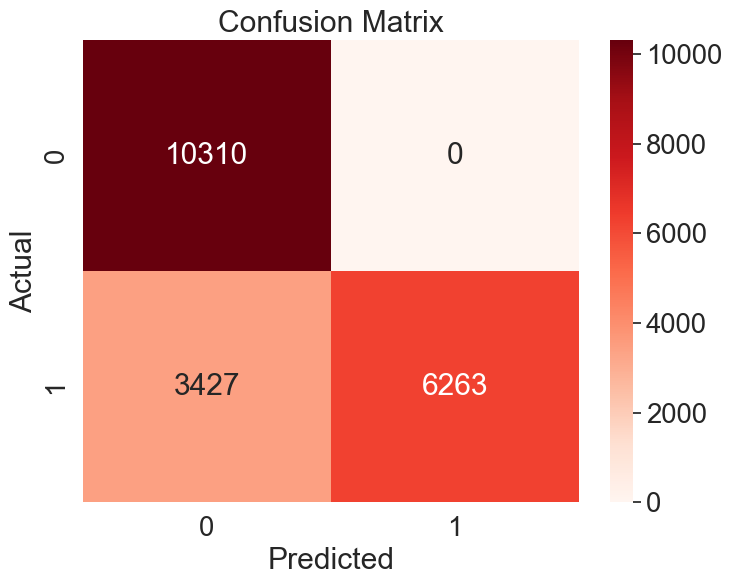

In [62]:
#Visualize a confusion matrix using heatmap 
#This Provides a clear graphical representation of the confusion matrix

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.8)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

AUC Score: 0.8217779085701359


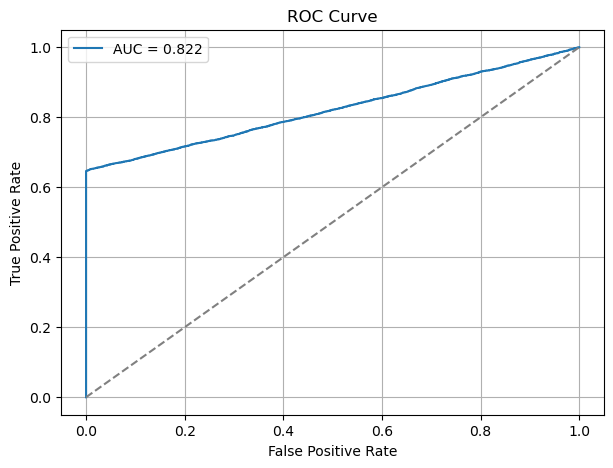

In [55]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Fit logistic regression
# model = LogisticRegression().fit(X_train, y_train)

# 2. Generate predicted probabilities for the positive class (1)
y_pred_proba = cls.predict_proba(X_test)[:, 1]

# 3. Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC Score:", auc_score)

# 4. ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()